## Building a SocialIQA Eval

This notebook shows how to:
- Build and run an eval
- Load the results and into a Pandas Dataframe

We use the `evals.elsuite.basic.match:Match` Eval class here to check whether new completions match the correct answer. Under the hood, it will generate a completion with the choice of model for each prompt, check if the completion matches the true answer, then logs a result.

In [1]:
import openai
import dotenv
import os
import pandas as pd

In [2]:
# load the OpenAI API key
dotenv.load_dotenv()
openai.api_key = os.getenv("OPENAI_API_KEY")

In [3]:
# Path to the SocialIQA folder
data_path = "../../datasets/socialiqa-train-dev"

In [4]:
# Assuming this notebook is in examples/
registry_path = os.path.join(os.getcwd(), "../evals/registry")

In [16]:
# Build the prompts using Chat format. We support converting Chat conversations to text for non-Chat models

choices = ["1", "2", "3"]
sys_msg = "The following are multiple choice questions (with answers) about social commonsense intelligence. Answer with the number corresponding to the correct answer."
def create_chat_prompt(sys_msg, context, question, answers):
    user_prompt = f"{context} {question}\n" + "\n".join([f"{choice}. {answer}" for choice, answer in zip(choices, answers)])
    return [
        {"role": "system", "content": sys_msg}, 
        {"role": "user", "content": user_prompt}
    ]

def create_chat_example(question, answers, correct_answer):
    """
    Form few-shot prompts in the recommended format: https://github.com/openai/openai-python/blob/main/chatml.md#few-shot-prompting
    """
    user_prompt = f"{question}\n" + "\n".join([f"{choice}. {answer}" for choice, answer in zip(choices, answers)]) + "\nAnswer:"
    return [
        {"role": "system", "content": user_prompt, "name": "example_user"},
        {"role": "system", "content": correct_answer, "name": "example_assistant"},
    ]

Load the SocialIQA data

In [17]:
test_df = pd.read_json(os.path.join(data_path, "train.jsonl"), lines=True)
labels_train = []
with open(os.path.join(data_path, "train-labels.lst"), 'rb') as f:
    # go line by line and add to the list
    for line in f:
        labels_train.append(line.decode('utf-8').strip())

# add labels_train as a column to test_df
test_df['correct_answer'] = labels_train

test_df.head()

,context,question,answerA,answerB,answerC,correct_answer
0,Cameron decided to have a barbecue and gathere...,How would Others feel as a result?,like attending,like staying home,a good friend to have,1
1,Jan needed to give out jobs for an upcoming pr...,What will Others want to do next?,disagree with Jan,get to work,argue with the assignments,2
2,Remy was an expert fisherman and was on the wa...,What will Remy want to do next?,cast the line,put the boat in the water,invite Kai out on the boat,1
3,Addison gave a hug to Skylar's son when they w...,Why did Addison do this?,better,wrong,keep hugging the son,1
4,Kai found one for sale online but it was too m...,What does Kai need to do before this?,cheaper,Open up her laptop,save money,2


Set the data in the right format and write in the registry 

In [18]:
import yaml

registry_yaml = {}

registry_data_path = os.path.join(registry_path, "data", "social_iqa")
os.makedirs(registry_data_path, exist_ok=True)

# Create few-shot prompts
# dev_df = pd.read_csv(os.path.join(data_path, "dev", subject + "_dev.csv"), names=("Question", "A", "B", "C", "D", "Answer"))
# dev_df["sample"] = dev_df.apply(lambda x: create_chat_example(x["Question"], x[["A", "B", "C", "D"]], x["Answer"]), axis=1)
# few_shot_path = os.path.join(registry_data_path, "few_shot.jsonl")     
# dev_df[["sample"]].to_json(few_shot_path, lines=True, orient="records")

# Create test prompts and ideal completions
test_df["input"] = test_df.apply(lambda x: create_chat_prompt(sys_msg, x["context"], x["question"], x[["answerA", "answerB", "answerC"]]), axis=1)
test_df["ideal"] = test_df.correct_answer
samples_path = os.path.join(registry_data_path, "samples.jsonl")     
test_df[["input", "ideal"]].to_json(samples_path, lines=True, orient="records")

eval_id = f"social_iqa"

registry_yaml[eval_id] = {
    "id": f"{eval_id}.test.v1",
    "metrics": ["accuracy"]
}
registry_yaml[f"{eval_id}.test.v1"] = {
    "class": "evals.elsuite.basic.match:Match",
    "args": {
        "samples_jsonl": samples_path,
        # "few_shot_jsonl": few_shot_path,  # I don't think this makes sense here
        # "num_few_shot": 4,
    }
}

with open(os.path.join(registry_path, "evals", "social_iqa.yaml"), "w") as f:
    yaml.dump(registry_yaml, f)

Test the eval. I will use the cheapest model for now. [ note the free code-davinci-002 is not available  ]

Setting `--record_path=<path>` stores the logs in a specific path

In [23]:
# This will generate a JSONL which will record samples and logs and store it in /tmp/evallogs
# !oaieval gpt-3.5-turbo social_iqa
!oaieval text-ada-001 social_iqa --max_samples 2 --record_path=../results/social_iqa/text-ada-001.jsonl --dry-run

[2023-10-17 16:13:19,615] [registry.py:254] Loading registry from /home/lorenzo/Dropbox/RECOG-AI/code/evals/evals/registry/evals
[2023-10-17 16:13:21,098] [registry.py:254] Loading registry from /home/lorenzo/.evals/evals
[2023-10-17 16:13:21,775] [registry.py:254] Loading registry from /home/lorenzo/Dropbox/RECOG-AI/code/evals/evals/registry/completion_fns
[2023-10-17 16:13:21,787] [registry.py:254] Loading registry from /home/lorenzo/.evals/completion_fns
[2023-10-17 16:13:21,787] [registry.py:148] completion_fn 'code-davinci-002' not found. Closest matches: ['cot/text-davinci-003']
Traceback (most recent call last):
  File "/home/lorenzo/venv/recog-evals/bin/oaieval", line 8, in <module>
    sys.exit(main())
  File "/home/lorenzo/Dropbox/RECOG-AI/code/evals/evals/cli/oaieval.py", line 274, in main
    run(args)
  File "/home/lorenzo/Dropbox/RECOG-AI/code/evals/evals/cli/oaieval.py", line 143, in run
    completion_fn_instances = [
  File "/home/lorenzo/Dropbox/RECOG-AI/code/evals/ev

Now check which models are available through this library

In [32]:
! export INSTRUCT_MODELS=( text-ada-001 text-babbage-001 text-curie-001 text-davinci-001 text-davinci-002 text-davinci-003 ); for model in "${INSTRUCT_MODELS[@]}"; do oaieval $model social_iqa --max_samples 2 --record_path=../results/social_iqa/$model.jsonl --dry-run; done

[2023-10-17 16:19:16,403] [registry.py:254] Loading registry from /home/lorenzo/Dropbox/RECOG-AI/code/evals/evals/registry/evals
[2023-10-17 16:19:17,693] [registry.py:254] Loading registry from /home/lorenzo/.evals/evals
[2023-10-17 16:19:18,292] [oaieval.py:189] Run started: 231017151918F4UQ33KP
[2023-10-17 16:19:18,293] [data.py:90] Fetching /home/lorenzo/Dropbox/RECOG-AI/code/evals/examples/../evals/registry/data/social_iqa/samples.jsonl
[2023-10-17 16:19:18,649] [eval.py:34] Evaluating 2 samples
[2023-10-17 16:19:18,657] [eval.py:142] Running in threaded mode with 10 threads!
  0%|                                                     | 0/2 [00:00<?, ?it/s][2023-10-17 16:19:19,009] [registry.py:254] Loading registry from /home/lorenzo/Dropbox/RECOG-AI/code/evals/evals/registry/evals
[2023-10-17 16:19:20,340] [registry.py:254] Loading registry from /home/lorenzo/.evals/evals
[2023-10-17 16:19:20,341] [record.py:304] Not recording event: Event(run_id='231017151918F4UQ33KP', event_id=0

In [33]:
! GPT_MODELS=( ada babbage curie davinci code-davinci-002 ); for model in "${GPT_MODELS[@]}"; do oaieval $model social_iqa --max_samples 2 --record_path=../results/social_iqa/$model.jsonl --dry-run; done

[2023-10-17 16:20:30,502] [registry.py:254] Loading registry from /home/lorenzo/Dropbox/RECOG-AI/code/evals/evals/registry/evals
[2023-10-17 16:20:31,893] [registry.py:254] Loading registry from /home/lorenzo/.evals/evals
[2023-10-17 16:20:32,591] [oaieval.py:189] Run started: 231017152032VUAYKZR5
[2023-10-17 16:20:32,593] [data.py:90] Fetching /home/lorenzo/Dropbox/RECOG-AI/code/evals/examples/../evals/registry/data/social_iqa/samples.jsonl
[2023-10-17 16:20:32,930] [eval.py:34] Evaluating 2 samples
[2023-10-17 16:20:32,946] [eval.py:142] Running in threaded mode with 10 threads!
  0%|                                                     | 0/2 [00:00<?, ?it/s][2023-10-17 16:20:33,673] [registry.py:254] Loading registry from /home/lorenzo/Dropbox/RECOG-AI/code/evals/evals/registry/evals
[2023-10-17 16:20:34,721] [registry.py:254] Loading registry from /home/lorenzo/.evals/evals
[2023-10-17 16:20:34,721] [record.py:304] Not recording event: Event(run_id='231017152032VUAYKZR5', event_id=0

Notice that `--dry-run` still calls the models, but it does not store results on disk.

<Axes: title={'center': 'Correctness of generated answers'}, xlabel='Correctness', ylabel='Count'>

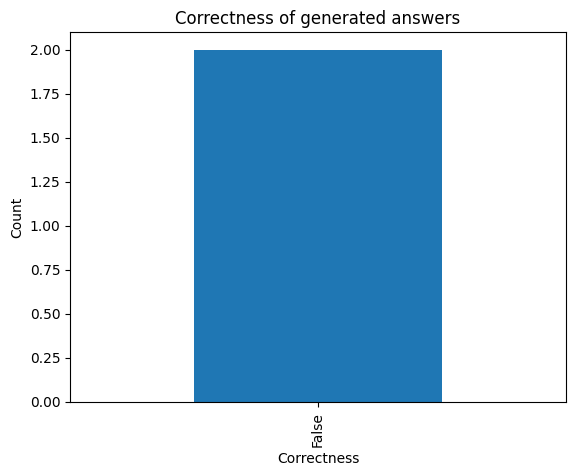

In [20]:
# How to process the log events generated by oaieval
events = "../results/social_iqa/text-ada-001.jsonl"

with open(events, "r") as f:
    events_df = pd.read_json(f, lines=True)

matches_df = events_df[events_df.type == "match"].reset_index(drop=True)
matches_df = matches_df.join(pd.json_normalize(matches_df.data))
matches_df.correct.value_counts().plot.bar(title="Correctness of generated answers", xlabel="Correctness", ylabel="Count")

In [21]:
# Inspect samples
for i, r in pd.json_normalize(events_df[events_df.type == "sampling"].data).iterrows():
    print(f"Prompt: {r.prompt}")
    print(f"Sampled: {r.sampled}")
    print("-" * 25)

Prompt: The following are multiple choice questions (with answers) about social commonsense intelligence. Answer with the number corresponding to the correct answer.
User: Riley ran away from Casey after they hurt Casey badly. What will happen to Casey?
1. be hurt
2. be fine
3. Nothing will happen to Casey
Assistant: 
Sampled: ['\n\n1. If Riley ran away from Casey, she would be hurt.']
-------------------------
Prompt: The following are multiple choice questions (with answers) about social commonsense intelligence. Answer with the number corresponding to the correct answer.
User: Remy died in a tragic accident and Aubrey was shocked to hear the news.  Aubrey sat taking it all in while memories of Remy ran through Aubrey's mind. How would Aubrey feel as a result?
1. Nothing
2. Happy
3. Sad
Assistant: 
Sampled: ['\n\n1. Nothing\n2. Happy\n3. Sad']
-------------------------
